# Introduction to Polynomials

This notebook follows the same style as the previous notebooks and introduces **polynomials** in a structured way.

It covers:

- what a polynomial is
- monomials, coefficients, and variable powers
- addition, subtraction, multiplication
- substitution / evaluation
- degree of a polynomial
- degree rules for addition and multiplication
- roots of polynomials
- repeated roots
- factorization
- Python examples and plots


## 1. What is a polynomial?

A polynomial in one variable $x$ is an expression of the form

$$
c_0 + c_1x + c_2x^2 + \dots + c_nx^n
$$

or, more compactly,

$$
\sum_{k=0}^{n} c_k x^k
$$

where:

- $c_0, c_1, \dots, c_n$ are **coefficients**
- $x$ is the **variable**
- each term $c_kx^k$ is called a **monomial**


### Example

$$
P(x)=3x^4-2x^2+5x-7
$$

has monomials:

- $3x^4$
- $-2x^2$
- $5x$
- $-7$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x')
P = 3*x**4 - 2*x**2 + 5*x - 7
P


3*x**4 - 2*x**2 + 5*x - 7

## 2. Main operations on polynomials

The basic operations are:

- addition
- subtraction
- multiplication
- substitution (evaluation)


## 3. Addition of polynomials

To add polynomials, we add coefficients of the same powers of $x$.

Example:

$$
(2x^2+5x+6) + (x^2+2x+1)
$$

Group like terms:

$$
(2+1)x^2 + (5+2)x + (6+1)
$$

so:

$$
= 3x^2 + 7x + 7
$$


In [2]:
P1 = 2*x**2 + 5*x + 6
P2 = x**2 + 2*x + 1

sp.expand(P1 + P2)


3*x**2 + 7*x + 7

Even if one polynomial is missing some powers, the same idea works.

Example:

$$
(4x^4+3x+5) + (2x^3+4x+2)
$$

becomes

$$
4x^4 + 2x^3 + 7x + 7
$$


In [3]:
P3 = 4*x**4 + 3*x + 5
P4 = 2*x**3 + 4*x + 2

sp.expand(P3 + P4)


4*x**4 + 2*x**3 + 7*x + 7

## 4. Subtraction of polynomials

Subtraction works exactly like addition, except we subtract coefficients.

Example:

$$
(2x^2 - 4x + 3) - (x^2 + x - 4)
$$

becomes

$$
x^2 - 5x + 7
$$


In [4]:
P5 = 2*x**2 - 4*x + 3
P6 = x**2 + x - 4

sp.expand(P5 - P6)


x**2 - 5*x + 7

## 5. Multiplication of polynomials

To multiply two polynomials, multiply **every term** in the first polynomial by **every term** in the second polynomial, then combine like terms.

Example:

$$
(x^2+5x+3)(3x-4)
$$

Expanding:

$$
x^2(3x-4)+5x(3x-4)+3(3x-4)
$$

$$
= 3x^3 - 4x^2 + 15x^2 - 20x + 9x - 12
$$

$$
= 3x^3 + 11x^2 - 11x - 12
$$


In [5]:
P7 = x**2 + 5*x + 3
P8 = 3*x - 4

sp.expand(P7 * P8)


3*x**3 + 11*x**2 - 11*x - 12

## 6. Substitution / evaluation

To evaluate a polynomial at a number, substitute that number for $x$.

Example:

$$
P(x)=5x^4 - 2x^2 + 4x + 11
$$

Then:

$$
P(2)=5\cdot 2^4 - 2\cdot 2^2 + 4\cdot 2 + 11 = 91
$$


In [6]:
P9 = 5*x**4 - 2*x**2 + 4*x + 11
P9.subs(x, 2)


91

## 7. Degree of a polynomial

The **degree** of a polynomial is the highest power of $x$ with a nonzero coefficient.

Example:

$$
3x^4 + 2x^2 - x^2 - 14
$$

simplifies to

$$
3x^4 + x^2 - 14
$$

so its degree is:

$$
4
$$


In [7]:
P10 = 3*x**4 + 2*x**2 - x**2 - 14
sp.expand(P10), sp.Poly(sp.expand(P10), x).degree()


(3*x**4 + x**2 - 14, 4)

## 8. Degree after addition

If two polynomials have degrees $a$ and $b$, then after addition the degree is usually

$$
\max(a,b)
$$

provided the leading terms do not cancel out.

Example:

$$
(2x^2+5) + (4x-6) = 2x^2 + 4x - 1
$$

The degrees were:

- degree of $2x^2+5$ is 2
- degree of $4x-6$ is 1

The result has degree 2.


In [8]:
A = 2*x**2 + 5
B = 4*x - 6
S = sp.expand(A + B)

print("A =", A, "degree =", sp.Poly(A, x).degree())
print("B =", B, "degree =", sp.Poly(B, x).degree())
print("A+B =", S, "degree =", sp.Poly(S, x).degree())


A = 2*x**2 + 5 degree = 2
B = 4*x - 6 degree = 1
A+B = 2*x**2 + 4*x - 1 degree = 2


### Important exception

Leading terms can cancel.

For example:

$$
x^2 + (-x^2+1)=1
$$

So the result can have smaller degree than $\max(a,b)$.


In [9]:
A = x**2
B = -x**2 + 1
S = sp.expand(A + B)

print("A+B =", S)
print("degree =", sp.Poly(S, x).degree())


A+B = 1
degree = 0


## 9. Degree after multiplication

If two polynomials have degrees $a$ and $b$, then the product has degree

$$
a+b
$$

Example:

$$
(2x^2+5)(4x-6)=8x^3-12x^2+20x-30
$$

The degrees were 2 and 1, and the result has degree 3.


In [10]:
A = 2*x**2 + 5
B = 4*x - 6
M = sp.expand(A * B)

print("A =", A, "degree =", sp.Poly(A, x).degree())
print("B =", B, "degree =", sp.Poly(B, x).degree())
print("A*B =", M, "degree =", sp.Poly(M, x).degree())


A = 2*x**2 + 5 degree = 2
B = 4*x - 6 degree = 1
A*B = 8*x**3 - 12*x**2 + 20*x - 30 degree = 3


## 10. Plotting polynomials

Polynomials are numerical functions, so we can plot them.

Example:

$$
P(x)=x^3 - 4x^2 + 5x - 2
$$


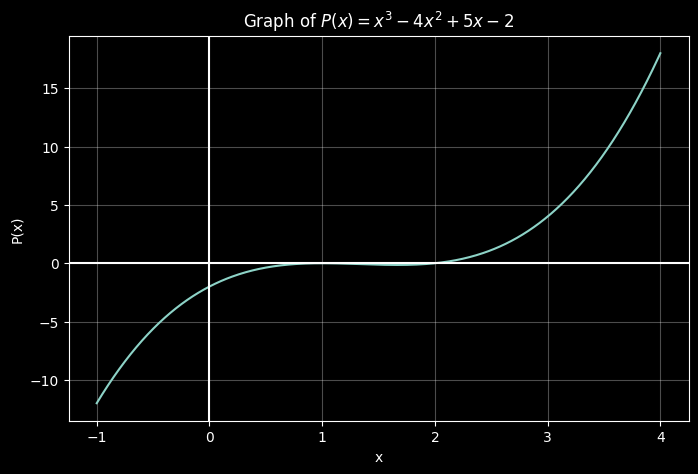

In [11]:
P_plot = x**3 - 4*x**2 + 5*x - 2
f_plot = sp.lambdify(x, P_plot, 'numpy')

xs = np.linspace(-1, 4, 500)
ys = f_plot(xs)

plt.figure(figsize=(8,5))
plt.plot(xs, ys)
plt.axhline(0)
plt.axvline(0)
plt.title(r"Graph of $P(x)=x^3-4x^2+5x-2$")
plt.xlabel("x")
plt.ylabel("P(x)")
plt.grid(True, alpha=0.3)
plt.show()


## 11. Roots of a polynomial

A **root** (or zero) of a polynomial is a number $r$ such that

$$
P(r)=0
$$

Example:

$$
P(x)=x^3 - 4x^2 + 5x - 2
$$

has $x=1$ as a root if substitution gives zero.


In [12]:
P_root = x**3 - 4*x**2 + 5*x - 2
print("P(1) =", sp.expand(P_root).subs(x, 1))
print("P(2) =", sp.expand(P_root).subs(x, 2))


P(1) = 0
P(2) = 0


## 12. A polynomial of degree $n$ has at most $n$ roots

A polynomial of degree $n$ can have no more than $n$ roots.

For example, a quadratic polynomial can have at most two roots.


In [13]:
Q = 4*x**2 + 2*x - 6
sp.solve(sp.Eq(Q, 0), x)


[-3/2, 1]

For

$$
4x^2+2x-6
$$

the roots are:

$$
1 \quad \text{and} \quad -1.5
$$


## 13. Real and complex roots

Some polynomials have roots that are not real numbers.

Example:

$$
x^2 - x + 3 = 0
$$

has complex roots.


In [14]:
Q_complex = x**2 - x + 3
sp.solve(sp.Eq(Q_complex, 0), x)


[1/2 - sqrt(11)*I/2, 1/2 + sqrt(11)*I/2]

## 14. Factorization

A polynomial can often be written as a product of simpler factors.

For example:

$$
x^2 - 5x + 6 = (x-2)(x-3)
$$

Factorization is closely connected with roots:

- if $r$ is a root, then $(x-r)$ is a factor


In [15]:
P_fact = x**2 - 5*x + 6
sp.factor(P_fact)


(x - 3)*(x - 2)

## 15. Repeated roots

A root is **repeated** if its factor appears more than once.

Example:

$$
x^3 - 4x^2 + 5x - 2
$$

factorizes as:

$$
(x-2)(x-1)^2
$$

So:

- $x=2$ is a root of multiplicity 1
- $x=1$ is a repeated root of multiplicity 2


In [16]:
P_repeat = x**3 - 4*x**2 + 5*x - 2
sp.factor(P_repeat)


(x - 2)*(x - 1)**2

## 16. Checking repeated roots by substitution

We can verify that both 1 and 2 are roots.


In [17]:
for r in [1, 2]:
    print(f"P({r}) =", P_repeat.subs(x, r))


P(1) = 0
P(2) = 0


## 17. Polynomial coefficients in Python

SymPy can extract coefficients and degree.


In [18]:
P = 3*x**4 - 2*x**2 + 5*x - 7
poly = sp.Poly(P, x)

print("Polynomial:", P)
print("Degree:", poly.degree())
print("Coefficients:", poly.all_coeffs())


Polynomial: 3*x**4 - 2*x**2 + 5*x - 7
Degree: 4
Coefficients: [3, 0, -2, 5, -7]


## 18. Using NumPy for numerical polynomial work

NumPy also has tools for numerical polynomial computations.


In [19]:
# Represents 3x^2 + 2x - 5
coeffs = [3, 2, -5]
p = np.poly1d(coeffs)

print("p(x) =", p)
print("p(2) =", p(2))
print("roots =", p.r)


p(x) =    2
3 x + 2 x - 5
p(2) = 11
roots = [-1.66666667  1.        ]


## 19. Example: addition, multiplication, and evaluation together

Let

$$
P(x)=x^2+2x+1
$$

and

$$
Q(x)=x-3
$$

Then we can compute:

- $P+Q$
- $PQ$
- $P(2)$


In [20]:
P = x**2 + 2*x + 1
Q = x - 3

print("P+Q =", sp.expand(P + Q))
print("P*Q =", sp.expand(P * Q))
print("P(2) =", P.subs(x, 2))


P+Q = x**2 + 3*x - 2
P*Q = x**3 - x**2 - 5*x - 3
P(2) = 9


## 20. A visual example of roots

The roots of a polynomial are the $x$-values where its graph crosses or touches the $x$-axis.


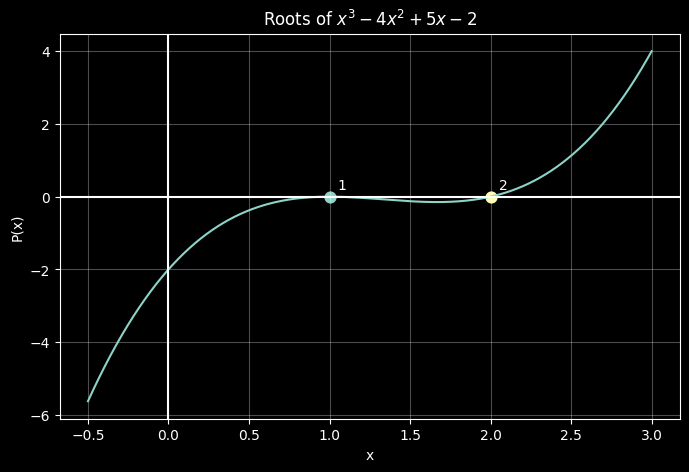

Roots: [1, 2]


In [21]:
P_vis = x**3 - 4*x**2 + 5*x - 2
f_vis = sp.lambdify(x, P_vis, 'numpy')
roots_vis = sp.solve(sp.Eq(P_vis, 0), x)

xs = np.linspace(-0.5, 3, 500)
ys = f_vis(xs)

plt.figure(figsize=(8,5))
plt.plot(xs, ys)
plt.axhline(0)
plt.axvline(0)

for r in roots_vis:
    if r.is_real:
        rr = float(r)
        plt.scatter(rr, 0, s=60)
        plt.text(rr + 0.05, 0.2, f"{rr:g}")

plt.title(r"Roots of $x^3-4x^2+5x-2$")
plt.xlabel("x")
plt.ylabel("P(x)")
plt.grid(True, alpha=0.3)
plt.show()

print("Roots:", roots_vis)


## 21. Summary of main ideas

A polynomial:

- is a sum of monomials
- has coefficients and powers of $x$
- can be added, subtracted, multiplied, and evaluated
- has a degree equal to the highest power of $x$
- may have real or complex roots
- can often be factorized into simpler factors
- may have repeated roots


## 22. Exercises

1. Add:
$$
(3x^2+2x+1)+(x^2-5x+4)
$$

2. Multiply:
$$
(x+2)(x-5)
$$

3. Evaluate:
$$
P(x)=2x^3-x+4 \quad \text{at } x=2
$$

4. Find the degree of:
$$
7x^5-3x^2+1
$$

5. Factor:
$$
x^2-9
$$


In [22]:
# Sample answers

print("1.", sp.expand((3*x**2 + 2*x + 1) + (x**2 - 5*x + 4)))
print("2.", sp.expand((x + 2) * (x - 5)))
print("3.", (2*x**3 - x + 4).subs(x, 2))
print("4.", sp.Poly(7*x**5 - 3*x**2 + 1, x).degree())
print("5.", sp.factor(x**2 - 9))


1. 4*x**2 - 3*x + 5
2. x**2 - 3*x - 10
3. 18
4. 5
5. (x - 3)*(x + 3)


## 23. Conclusion

Polynomials are among the most important objects in mathematics.

They appear in:

- algebra
- geometry
- calculus
- physics
- chemistry
- economics
- engineering

Understanding their operations, degree, roots, and factorization is essential for more advanced mathematics.
